# OpenSearch Semantic Image Search with Amazon Nova Multimodal Embeddings

This notebook demonstrates semantic image search using **OpenSearch Serverless** as the vector store,
combined with **Amazon Nova Multimodal Embeddings** for query embedding generation.

**Pipeline**
1. Connect to OpenSearch Serverless collection
2. Pick a query image and generate its embedding using **Nova Multimodal Embeddings**
3. Run k-NN search to find the **5 most visually similar** photos

**AWS services**
| Service | Role |
|---|---|
| Amazon OpenSearch Serverless | Vector store & k-NN search |
| Amazon Bedrock | Nova Multimodal Embeddings (`amazon.nova-2-multimodal-embeddings-v1:0`) |

In [1]:
%pip install boto3 opensearch-py requests-aws4auth "pillow>=10" requests matplotlib --quiet

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# ================================================================
# CONFIGURATION
# ================================================================

# OpenSearch Serverless endpoint
OPENSEARCH_ENDPOINT = "aoss url endpoint"
INDEX_NAME = "photos-index-1773217376"

# Amazon Nova Multimodal Embeddings model (same as used for indexing)
EMBEDDING_MODEL_ID  = "amazon.nova-2-multimodal-embeddings-v1:0"
EMBEDDING_DIMENSION = 1024

# AWS credentials (use default credentials)
AWS_REGION = "us-east-1"

# Similarity search — how many neighbours to retrieve
TOP_K = 5

# Query image (same as in s3Vectors notebook for comparison)
QUERY_IMAGE_URL = "https://images.unsplash.com/photo-1446367819189-c48fb912db4d"
QUERY_IMAGE_ID = "PuobOOUjX5I"
QUERY_IMAGE_DESC = "greyscale photo of an island under white clouds"

In [3]:
import json
import base64
import io
import time
import warnings

import boto3
import requests
import matplotlib.pyplot as plt
from PIL import Image
from opensearchpy import OpenSearch, RequestsHttpConnection
from requests_aws4auth import AWS4Auth

%matplotlib inline
warnings.filterwarnings("ignore")

print("Libraries loaded ✓")

Libraries loaded ✓


---
## Step 1 — Create AWS Clients

Two clients:
- **`bedrock-runtime`** — calls the Nova Multimodal Embeddings model
- **`OpenSearch`** — connects to OpenSearch Serverless with AWS SigV4 authentication

In [4]:
# Create boto3 session (default credentials)
session = boto3.Session(region_name=AWS_REGION)
credentials = session.get_credentials()

# Bedrock client for embeddings
bedrock_runtime = session.client("bedrock-runtime")

# AWS4Auth for OpenSearch Serverless (service name is 'aoss')
awsauth = AWS4Auth(
    credentials.access_key,
    credentials.secret_key,
    AWS_REGION,
    "aoss",  # OpenSearch Serverless service name
    session_token=credentials.token,
)

# OpenSearch client
host = OPENSEARCH_ENDPOINT.replace("https://", "").replace("http://", "")
opensearch_client = OpenSearch(
    hosts=[{"host": host, "port": 443}],
    http_auth=awsauth,
    use_ssl=True,
    verify_certs=True,
    connection_class=RequestsHttpConnection,
    timeout=30,
)

# Verify credentials
identity = session.client("sts").get_caller_identity()
print(f"AWS Account : {identity['Account']}")
print(f"IAM Identity: {identity['Arn']}")
print(f"Region      : {AWS_REGION}")
print()
print("AWS clients ready ✓")

AWS Account : 1234567890
IAM Identity: arn:aws:iam::1234567890:user/your_user
Region      : us-east-1

AWS clients ready ✓


---
## Step 2 — Verify OpenSearch Connection

Check that we can connect to the OpenSearch collection and verify the index exists.

In [5]:
# OpenSearch Serverless doesn't support info() - check index directly
print(f"OpenSearch Endpoint: {OPENSEARCH_ENDPOINT}")
print()

# List all indices in the collection
print("Available indices:")
indices = opensearch_client.cat.indices(format="json")
for idx in indices:
    print(f"  - {idx['index']} ({idx.get('docs.count', '?')} docs)")
print()

# Check if our target index exists
if opensearch_client.indices.exists(index=INDEX_NAME):
    count = opensearch_client.count(index=INDEX_NAME)
    print(f"Index '{INDEX_NAME}' exists ✓")
    print(f"Document count: {count['count']:,}")
    
    # Show index mapping to understand the vector field name
    mapping = opensearch_client.indices.get_mapping(index=INDEX_NAME)
    print(f"\nIndex mapping:")
    print(json.dumps(mapping, indent=2))
else:
    print(f"Index '{INDEX_NAME}' not found!")

OpenSearch Endpoint: your_aoss_endpoint_url

Available indices:
  - photos-index-1773217376 (1000 docs)

Index 'photos-index-1773217376' exists ✓
Document count: 1,000

Index mapping:
{
  "photos-index-1773217376": {
    "mappings": {
      "properties": {
        "key": {
          "type": "keyword"
        },
        "metadata": {
          "properties": {
            "description": {
              "type": "text",
              "fields": {
                "keyword": {
                  "type": "keyword",
                  "ignore_above": 256
                }
              }
            },
            "photographer": {
              "type": "text",
              "fields": {
                "keyword": {
                  "type": "keyword",
                  "ignore_above": 256
                }
              }
            },
            "url": {
              "type": "text",
              "fields": {
                "keyword": {
                  "type": "keyword",
                  "

---
## Step 3 — Generate Query Embedding

Using the same query image and embedding model as the S3 Vectors demo.

In [6]:
IMAGE_DOWNLOAD_SIZE = 512

def download_image(url: str, size: int = IMAGE_DOWNLOAD_SIZE) -> bytes:
    """Download image from URL with optional resize."""
    if "unsplash.com" in url and "?" not in url:
        url = f"{url}?w={size}&q=80&fit=max"
    resp = requests.get(url, timeout=20)
    resp.raise_for_status()
    return resp.content


def to_jpeg(raw: bytes) -> bytes:
    """Normalise any image format to JPEG."""
    img = Image.open(io.BytesIO(raw))
    buf = io.BytesIO()
    img.convert("RGB").save(buf, format="JPEG", quality=85, optimize=True)
    return buf.getvalue()


def generate_embedding(image_bytes: bytes) -> list:
    """Generate embedding using Nova Multimodal Embeddings."""
    jpeg = to_jpeg(image_bytes)
    b64 = base64.b64encode(jpeg).decode("utf-8")

    body = {
        "taskType": "SINGLE_EMBEDDING",
        "singleEmbeddingParams": {
            "embeddingPurpose": "GENERIC_INDEX",
            "embeddingDimension": EMBEDDING_DIMENSION,
            "image": {
                "format": "jpeg",
                "source": {"bytes": b64},
            },
        },
    }

    resp = bedrock_runtime.invoke_model(
        body=json.dumps(body),
        modelId=EMBEDDING_MODEL_ID,
        accept="application/json",
        contentType="application/json",
    )

    data = json.loads(resp["body"].read())
    return data["embeddings"][0]["embedding"]


print("Helper functions defined ✓")
print(f"  Model     : {EMBEDDING_MODEL_ID}")
print(f"  Dimension : {EMBEDDING_DIMENSION}")

Helper functions defined ✓
  Model     : amazon.nova-2-multimodal-embeddings-v1:0
  Dimension : 1024


In [7]:
print("Query image:")
print(f"  Photo ID    : {QUERY_IMAGE_ID}")
print(f"  Description : {QUERY_IMAGE_DESC}")
print(f"  URL         : {QUERY_IMAGE_URL}")

# Generate the query embedding
print("\nGenerating query embedding...")
query_bytes = download_image(QUERY_IMAGE_URL)
query_embedding = generate_embedding(query_bytes)
print(f"Embedding ready — {len(query_embedding)} dimensions ✓")

Query image:
  Photo ID    : PuobOOUjX5I
  Description : greyscale photo of an island under white clouds
  URL         : https://images.unsplash.com/photo-1446367819189-c48fb912db4d

Generating query embedding...
Embedding ready — 1024 dimensions ✓


---
## Step 4 — Semantic Image Search with OpenSearch k-NN

Run a k-NN query against OpenSearch to find the most similar images.

In [24]:
# First, find the knn_vector field name from the mapping
mapping = opensearch_client.indices.get_mapping(index=INDEX_NAME)
properties = mapping[INDEX_NAME]["mappings"]["properties"]

vector_field = None
for field_name, field_props in properties.items():
    if field_props.get("type") == "knn_vector":
        vector_field = field_name
        print(f"Found vector field: '{vector_field}'")
        break

if not vector_field:
    print("Available fields:")
    for field_name, field_props in properties.items():
        print(f"  - {field_name}: {field_props.get('type', 'unknown')}")
    raise ValueError("No knn_vector field found in index!")

print(f"\nSearching for top-{TOP_K} similar images...\n")

# Build k-NN query with the correct field name
knn_query = {
    "size": TOP_K,
    "query": {
        "knn": {
            vector_field: {
                "vector": query_embedding,
                "k": TOP_K,
            }
        }
    },
}

t0 = time.perf_counter()
response = opensearch_client.search(index=INDEX_NAME, body=knn_query)
elapsed_ms = (time.perf_counter() - t0) * 1_000

hits = response["hits"]["hits"]

print(f"Search time : {elapsed_ms:.1f} ms")
print(f"Total hits  : {len(hits)}")
print()
print(f"{'#':<4} {'Key':<15} {'Score':>10}  Description")
print("-" * 80)

results = []
for i, hit in enumerate(hits):
    source = hit["_source"]
    score = hit["_score"]
    key = source.get("key", hit["_id"])
    
    # Metadata is nested under 'metadata' field
    metadata = source.get("metadata", {})
    desc = str(metadata.get("description", ""))[:45]
    url = metadata.get("url", "")
    photographer = metadata.get("photographer", "")
    
    results.append({
        "key": key,
        "score": score,
        "url": url,
        "description": metadata.get("description", ""),
        "photographer": photographer,
    })
    
    print(f"{i+1:<4} {key:<15} {score:>10.4f}  {desc}")

Found vector field: 'vector_record'

Searching for top-5 similar images...

Search time : 47.2 ms
Total hits  : 5

#    Key                  Score  Description
--------------------------------------------------------------------------------
1    umr1gGpu5M0         0.8655  panoramic photography of mountain near body o
2    E-6ZENGgngU         0.8415  sea waves during nighttime
3    dB0NXVpvgTo         0.8279  view of boat on the sea under dark clouds
4    ZLFHNKQDWEE         0.8229  brown rock formation on water
5    _rsGm7nob3w         0.8190  stack landform under cloudy sky nature photog


---
## Results — Visual Comparison

> **Query image** is shown top-left (blue border).
> **Score** represents similarity (higher = more similar).

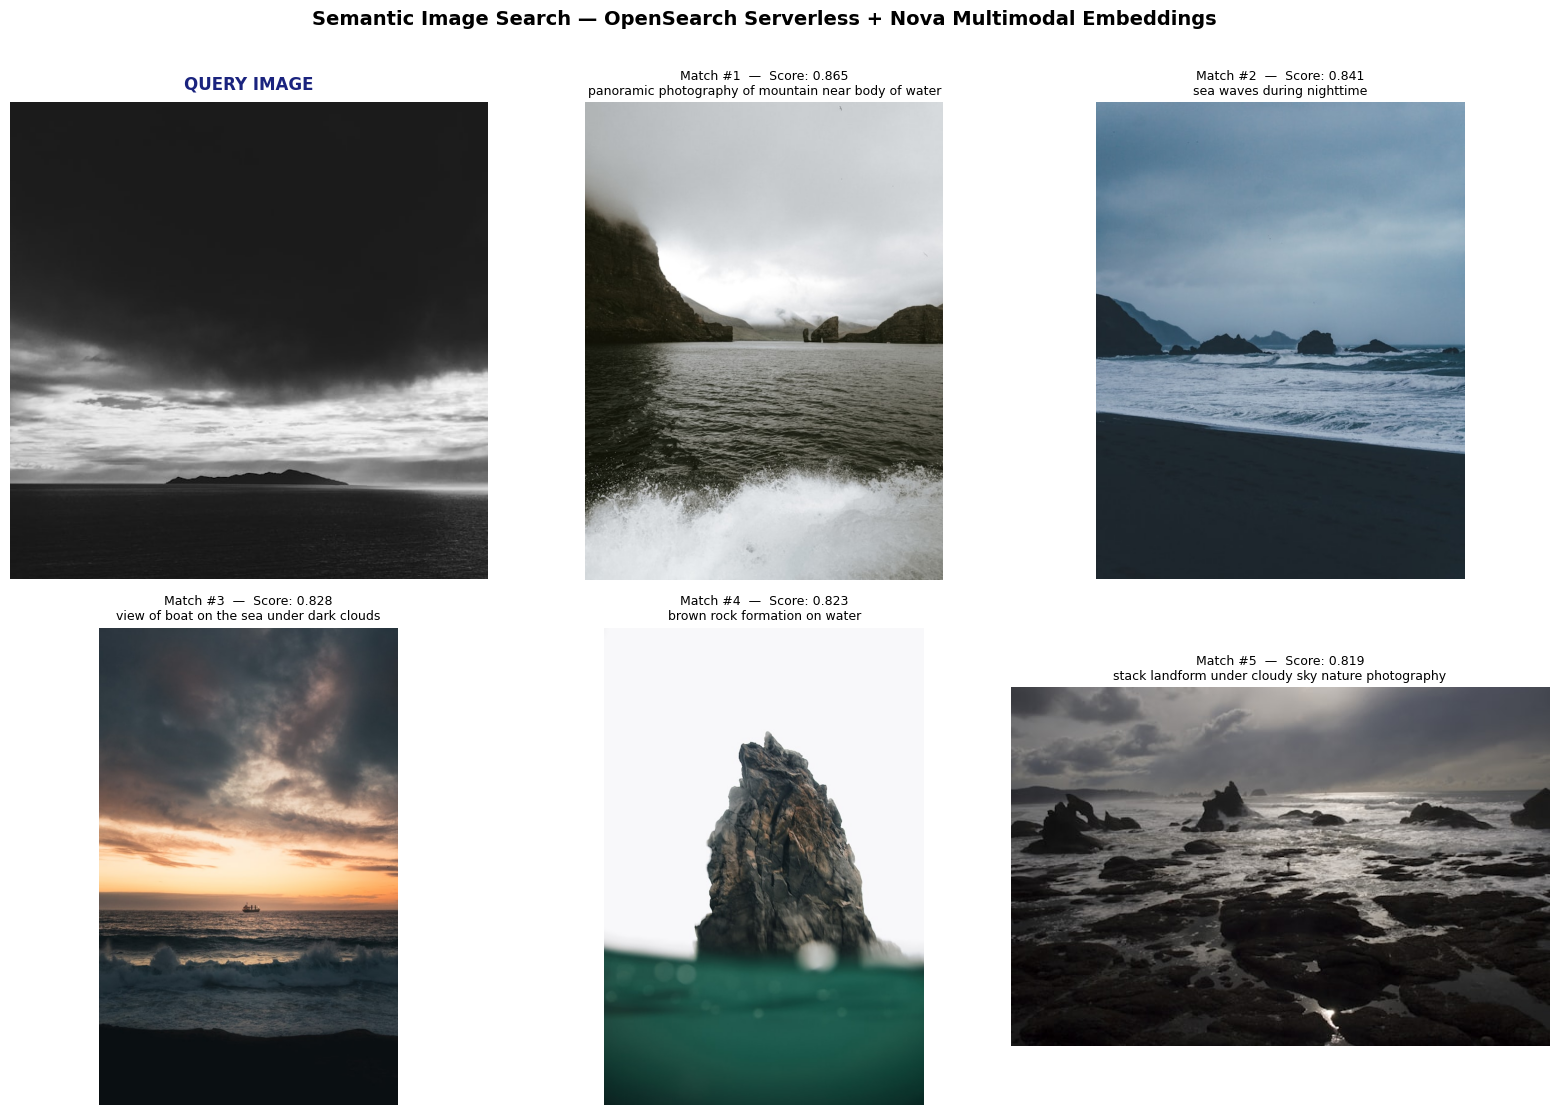


Query time  : 320.0 ms
Saved to    : opensearch_results.png


In [17]:
def load_img(url: str, size: int = 600) -> Image.Image:
    """Load image from URL."""
    if "unsplash.com" in url and "?" not in url:
        url = f"{url}?w={size}&q=80&fit=max"
    try:
        resp = requests.get(url, timeout=20)
        return Image.open(io.BytesIO(resp.content)).convert("RGB")
    except Exception:
        return Image.new("RGB", (size, size), color=(200, 200, 200))


# 2-row × 3-column grid
fig, axes = plt.subplots(2, 3, figsize=(16, 11))
fig.suptitle(
    "Semantic Image Search — OpenSearch Serverless + Nova Multimodal Embeddings",
    fontsize=14, fontweight="bold", y=1.01,
)

# --- Query image (top-left) -------------------------------------------------
ax_q = axes[0, 0]
ax_q.imshow(load_img(QUERY_IMAGE_URL))
ax_q.set_title("QUERY IMAGE", fontsize=12, fontweight="bold",
               color="#1a237e", pad=10)
ax_q.axis("off")
for spine in ax_q.spines.values():
    spine.set_visible(True)
    spine.set_edgecolor("#1a237e")
    spine.set_linewidth(5)

# --- 5 result images --------------------------------------------------------
result_positions = [(0, 1), (0, 2), (1, 0), (1, 1), (1, 2)]

for idx, (row_i, col_i) in enumerate(result_positions):
    ax = axes[row_i, col_i]
    if idx >= len(results):
        ax.axis("off")
        continue

    res = results[idx]
    url = res["url"]
    score = res["score"]
    desc = res["description"]
    phot = res["photographer"]

    ax.imshow(load_img(url))
    label = (
        f"Match #{idx+1}  —  Score: {score:.3f}\n"
        + (desc[:55] + ("…" if len(desc) > 55 else "") if desc else phot)
    )
    ax.set_title(label, fontsize=9, pad=6)
    ax.axis("off")

plt.tight_layout()
plt.savefig("opensearch_results.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nQuery time  : {elapsed_ms:.1f} ms")
print(f"Saved to    : opensearch_results.png")